# Volume Kedua Lambung Kapal Katamaran (tanpa reserve buoyancy)

**Nama:** Daffa Aqila Putra  |  **NPM:** 25083010016  |  **Kelas:** Analisis Numerik

Link GitHub: https://github.com/DaffaAqilaPutra/Analisis-Volume-lambung-kapal

**Soal:** Hitung volume kedua lambung kapal dari gambar katamaran fiberglass untuk wisata pancing.

**Ketentuan dari soal:**
- Satu *dash-kosong* = **5 + 5 cm**.
- Lantai kapal datar (tanpa *keel*), sehingga **tampak depan semuanya persegi panjang**.
- Volume *reserve buoyancy* (ujung buritan dan haluan) **tidak dihitung**.

## Ide Penyelesaian

Karena penampang depan berupa persegi panjang, luas penampang pada posisi $x$ adalah

$$A(x) = b(x)\cdot h(x)$$

- $b(x)$ = lebar lambung (dibaca dari tampak atas)
- $h(x)$ = tinggi lambung dari dek sampai dasar (dibaca dari tampak samping)

Volume lambung adalah jumlah semua irisan penampang sepanjang lambung:

$$V=\int_0^{L} A(x)\,dx$$

Karena $A(x)$ hanya diketahui di titik-titik pengukuran (stasiun) yang dibaca dari gambar, integral tidak bisa dihitung secara eksak, sehingga dihitung dengan **integrasi numerik** (Trapesium dan Simpson 1/3). Hasil satu lambung dikalikan 2 karena kedua lambung dianggap identik.

## 1. Menentukan Skala dari Dash

Garis grid hijau terbuat dari dash dan celah kosong yang bergantian.

- 1 dash-kosong = 5 cm + 5 cm = 10 cm
- Dari gambar, satu garis grid sepanjang 20 kotak memuat sekitar **85 pasang dash-kosong**
- Maka 1 kotak = 85 / 20 = 4,25 pasang = 4,25 x 10 cm = **42,5 cm**

Lambung utama (di antara dua daerah reserve buoyancy) membentang dari garis grid ke-3 sampai garis grid ke-19, yaitu **16 kotak**.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dash, kosong = 5, 5                      # cm
pasangan = dash + kosong                 # cm per dash-kosong

pasang_per_20_kotak = 85                 # hasil hitung dari gambar
pasang_per_kotak = pasang_per_20_kotak / 20
SKALA_KOTAK = pasang_per_kotak * pasangan   # cm per kotak

jumlah_kotak = 16
print(f"1 dash-kosong    = {pasangan} cm")
print(f"1 kotak grid     = {SKALA_KOTAK} cm")
print(f"Panjang lambung  = {jumlah_kotak} x {SKALA_KOTAK} = {jumlah_kotak*SKALA_KOTAK} cm = {jumlah_kotak*SKALA_KOTAK/100} m")

1 dash-kosong    = 10 cm
1 kotak grid     = 42.5 cm
Panjang lambung  = 16 x 42.5 = 680.0 cm = 6.8 m


## 2. Menentukan Stasiun dan Data Ukur

Lambung utama dibagi menjadi **32 interval** yang sama panjang, sehingga ada **33 stasiun** (nomor 4 sampai 36). Jarak antar stasiun adalah setengah kotak:

$$\Delta x = \frac{42{,}5}{2} = 21{,}25\ \text{cm}$$

- Stasiun 4 = garis grid ke-3, batas reserve buoyancy buritan
- Stasiun 36 = garis grid ke-19, batas reserve buoyancy haluan

Pada setiap stasiun dibaca:
- **Lebar $b$** dari tampak atas (tepi luar lambung). Pembacaan awal memakai anggapan 1 kotak = 40 cm, sehingga dikalikan faktor koreksi 42,5/40.
- **Tinggi $h$** dari tampak samping (garis sheer sampai dasar lambung). Tinggi sudah dicek langsung pada gambar dan sesuai dalam cm sebenarnya (sekitar 105 cm di bagian tengah), jadi tidak dikoreksi lagi.

Di bagian buritan tinggi lambung mengecil karena dasar kapal naik, sedangkan di bagian tengah dasar datar sehingga $h$ konstan. Lebar mengecil menuju haluan.

In [11]:
DX = SKALA_KOTAK / 2                 # cm, jarak antar stasiun (setengah kotak)
SKALA_BACA = 40.0                    # lebar semula dibaca dengan anggapan 1 kotak = 40 cm
faktor = SKALA_KOTAK / SKALA_BACA    # koreksi lebar ke skala yang benar

# (stasiun, lebar_cm, tinggi_cm); lebar pada skala 40 cm/kotak (dikoreksi di bawah), tinggi sudah dalam cm sebenarnya
DATA = [
    (4,70,75),(5,75,85),(6,75,90),(7,80,95),(8,85,100),
    (9,85,105),(10,85,105),(11,85,105),(12,85,105),(13,85,105),
    (14,85,105),(15,85,105),(16,85,105),(17,85,105),(18,85,105),
    (19,85,105),(20,85,105),(21,85,105),(22,85,105),(23,85,105),
    (24,85,105),(25,85,105),(26,85,105),(27,85,105),(28,85,105),
    (29,85,105),(30,80,105),(31,75,105),(32,75,105),(33,70,105),
    (34,65,105),(35,60,105),(36,50,105),
]

st     = np.array([d[0] for d in DATA])
lebar  = np.array([d[1] for d in DATA], dtype=float) * faktor   # cm
tinggi = np.array([d[2] for d in DATA], dtype=float)            # cm
x      = (st - st[0]) * DX                                      # cm
A      = lebar * tinggi                                         # cm^2

tabel = pd.DataFrame({"Stasiun": st, "x (cm)": x, "Lebar b (cm)": lebar.round(2),
                      "Tinggi h (cm)": tinggi, "Luas A = b x h (cm2)": A.round(1)})
tabel

,Stasiun,x (cm),Lebar b (cm),Tinggi h (cm),Luas A = b x h (cm2)
0,4,0.00,74.38,75.0,5578.1
1,5,21.25,79.69,85.0,6773.4
2,6,42.50,79.69,90.0,7171.9
3,7,63.75,85.00,95.0,8075.0
4,8,85.00,90.31,100.0,9031.2
5,9,106.25,90.31,105.0,9482.8
6,10,127.50,90.31,105.0,9482.8
7,11,148.75,90.31,105.0,9482.8
8,12,170.00,90.31,105.0,9482.8
9,13,191.25,90.31,105.0,9482.8


## 3. Rumus Integrasi Numerik

Dengan $n = 32$ interval dan jarak antar titik $\Delta x = 21{,}25$ cm:

**Metode Trapesium**

$$V \approx \Delta x\left[\frac{A_0 + A_n}{2} + A_1 + A_2 + \cdots + A_{n-1}\right]$$

Metode ini menghubungkan titik-titik $A(x)$ dengan garis lurus, sehingga tiap potongan berbentuk trapesium.

**Metode Simpson 1/3** (syarat: jumlah interval genap, di sini $n = 32$)

$$V \approx \frac{\Delta x}{3}\left[A_0 + 4(A_1 + A_3 + \cdots + A_{n-1}) + 2(A_2 + A_4 + \cdots + A_{n-2}) + A_n\right]$$

Metode ini mendekati $A(x)$ dengan parabola tiap dua interval, sehingga biasanya lebih teliti dibanding Trapesium.

Hasil satu lambung dikalikan 2 untuk mendapat volume kedua lambung:

$$V_{total} = 2\,V_{satu\ lambung}$$

In [12]:
def trapesium(y, dx):
    return dx * (y[0]/2 + y[1:-1].sum() + y[-1]/2)

def simpson(y, dx):   # butuh jumlah interval genap
    n = len(y) - 1
    assert n % 2 == 0, "Jumlah interval harus genap"
    return dx/3 * (y[0] + 4*y[1:-1:2].sum() + 2*y[2:-1:2].sum() + y[-1])

n_interval = len(st) - 1
print(f"Jumlah interval : {n_interval}")
print(f"Panjang lambung : {n_interval*DX:.0f} cm = {n_interval*DX/100:.2f} m")

V_trap = trapesium(A, DX)
V_simp = simpson(A, DX)

hasil = pd.DataFrame({
    "Metode": ["Trapesium", "Simpson 1/3"],
    "1 lambung (m3)": [V_trap/1e6, V_simp/1e6],
    "2 lambung (m3)": [2*V_trap/1e6, 2*V_simp/1e6],
    "2 lambung (liter)": [2*V_trap/1e3, 2*V_simp/1e3],
})
hasil

Jumlah interval : 32
Panjang lambung : 680 cm = 6.80 m


,Metode,1 lambung (m3),2 lambung (m3),2 lambung (liter)
0,Trapesium,6.017635,12.035270,12035.269531
1,Simpson 1/3,6.023844,12.047688,12047.687500


Jumlah interval : 32
Panjang lambung : 680 cm = 6.80 m

In [14]:
selisih = abs(V_simp - V_trap)
print(f"Selisih Simpson - Trapesium (1 lambung): {selisih/1e6:.5f} m3 ({selisih/V_simp*100:.3f} %)")
print(f"Volume 2 lambung (Simpson): {2*V_simp/1e6:.3f} m3 = {2*V_simp/1e3:,.0f} liter")

Selisih Simpson - Trapesium (1 lambung): 0.00621 m3 (0.103 %)
Volume 2 lambung (Simpson): 12.048 m3 = 12,048 liter


Kedua metode memberi hasil yang sangat dekat (selisih sekitar 0,1%). Ini wajar karena $A(x)$ berubah mulus dan bagian tengah lambung hampir konstan. Hasil Simpson 1/3 dipakai sebagai jawaban utama karena umumnya lebih teliti, sedangkan Trapesium dipakai sebagai pembanding. Selisih Simpson - Trapesium (1 lambung): 0.00621 m3 (0.103 %)
Volume 2 lambung (Simpson): 12.048 m3 = 12,048 liter

## 4. Visualisasi

Grafik pertama memperlihatkan lebar lambung dan luas penampang $A(x)$ sepanjang lambung. Grafik kedua memperlihatkan bentuk lambung dari atas (disusun dari lebar $b$) dan dari samping (dari tinggi $h$). Garis merah menandai batas reserve buoyancy yang tidak dihitung, dan garis hijau tipis menandai posisi stasiun.

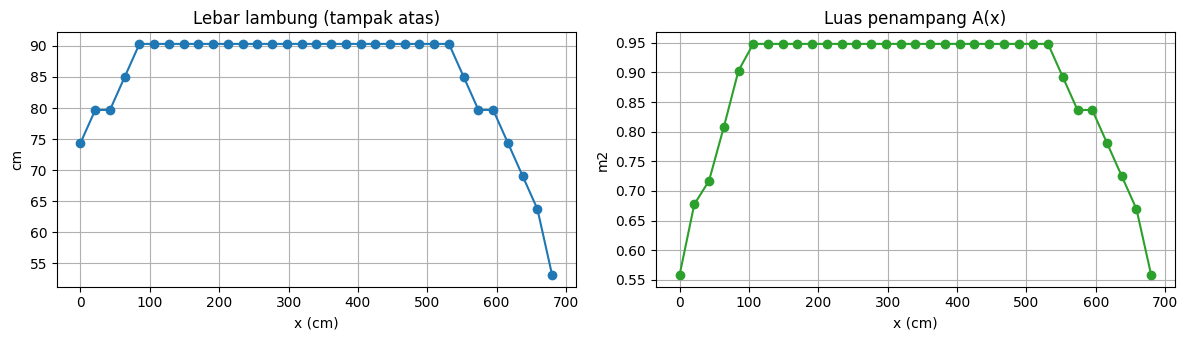

In [15]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.5))
a1.plot(x, lebar, "o-"); a1.set_title("Lebar lambung (tampak atas)")
a1.set_xlabel("x (cm)"); a1.set_ylabel("cm"); a1.grid(True)
a2.plot(x, A/1e4, "o-", color="tab:green"); a2.set_title("Luas penampang A(x)")
a2.set_xlabel("x (cm)"); a2.set_ylabel("m2"); a2.grid(True)
plt.tight_layout(); plt.show()

## 5. Visualisasi Tampak Atas dan Tampak Samping
Bentuk lambung dibangun dari lebar dan tinggi di tiap stasiun. Garis putus-putus hijau menandai posisi stasiun (tiap setengah kotak), dan stasiun pertama dan terakhir adalah batas dengan reserve buoyancy (tidak dihitung).

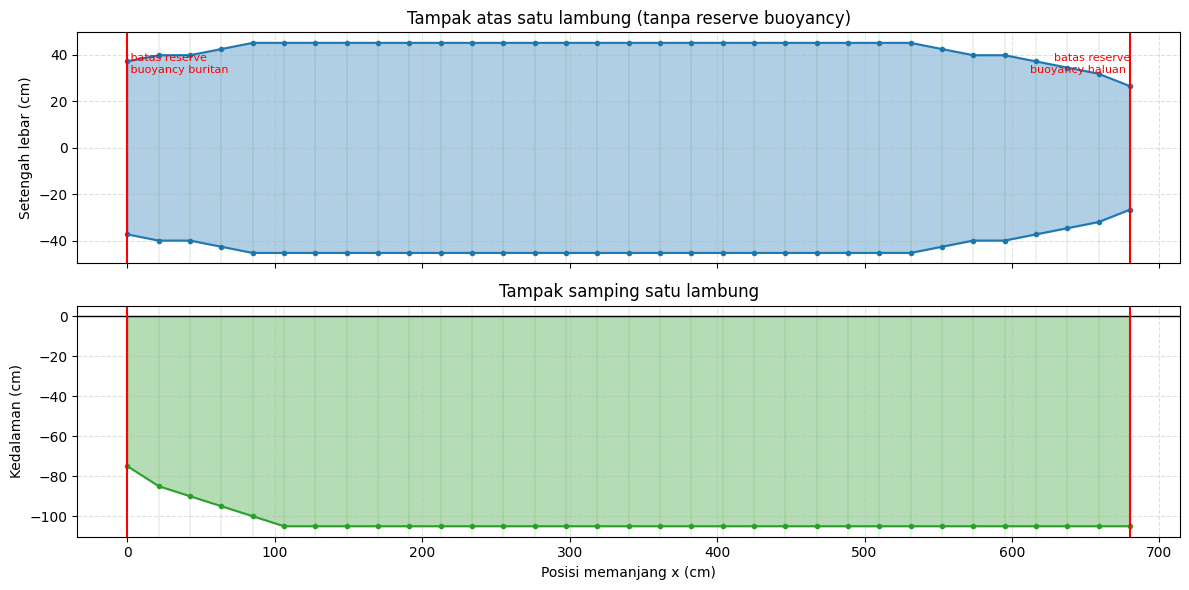

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Tampak atas: lebar lambung simetris terhadap sumbu tengah
ax1.fill_between(x, -lebar/2, lebar/2, alpha=0.35, color="tab:blue")
ax1.plot(x, lebar/2, "o-", ms=3, color="tab:blue")
ax1.plot(x, -lebar/2, "o-", ms=3, color="tab:blue")
ax1.set_ylabel("Setengah lebar (cm)")
ax1.set_title("Tampak atas satu lambung (tanpa reserve buoyancy)")

# Tampak samping: tinggi lambung (dek di atas, dasar datar)
ax2.fill_between(x, 0, -tinggi, alpha=0.35, color="tab:green")
ax2.plot(x, -tinggi, "o-", ms=3, color="tab:green")
ax2.axhline(0, color="k", lw=1)
ax2.set_ylabel("Kedalaman (cm)")
ax2.set_xlabel("Posisi memanjang x (cm)")
ax2.set_title("Tampak samping satu lambung")

for a in (ax1, ax2):
    a.grid(True, linestyle="--", alpha=0.4)
    for xv in x:
        a.axvline(xv, color="green", lw=0.3, alpha=0.4)
    a.axvline(x[0], color="red", lw=1.5)
    a.axvline(x[-1], color="red", lw=1.5)

ax1.text(x[0], lebar.max()/2*0.9, " batas reserve\n buoyancy buritan", color="red", fontsize=8, va="top")
ax1.text(x[-1], lebar.max()/2*0.9, "batas reserve\nbuoyancy haluan ", color="red", fontsize=8, va="top", ha="right")
plt.tight_layout()
plt.show()

## Kesimpulan

| Besaran | Satu lambung | Kedua lambung |
|---|---|---|
| Volume (Trapesium) | 6,018 m³ | 12,035 m³ |
| Volume (Simpson 1/3) | 6,024 m³ | **12,048 m³** (sekitar 12.050 liter) |

Catatan:
- Skala 1 kotak = 42,5 cm diperoleh dari 85 pasang dash-kosong per 20 kotak, dengan 1 dash-kosong = 10 cm. Panjang lambung utama 16 kotak = 6,8 m.
- Selisih Trapesium dan Simpson 1/3 hanya sekitar 0,1%, sehingga kedua metode konsisten.
- Hasil bergantung pada pembacaan lebar dan tinggi dari gambar, jadi selisih kecil (sekitar 1 sampai 3%) masih wajar. Jika data berubah, cukup ubah `pasang_per_20_kotak` dan `DATA` lalu jalankan ulang semua sel.
- Volume reserve buoyancy di ujung buritan dan haluan tidak dihitung sesuai perintah soal. Kedua lambung dianggap identik, sehingga volume total = 2 x volume satu lambung.